# Problem - Max Container Area

You are given an integer array height of length `n`. There are n vertical lines drawn such that the two endpoints of the ith line are `(i, 0)` and `(i, height[i])`. Find two lines that together with the **x-axis** form a container, such that the container contains the most water. Return the maximum amount of water a container can store.

**Input**: `height = [1,8,6,2,5,4,8,3,7]`
**Output**: `49`

**Explanation**: The above vertical lines are represented by array `[1,8,6,2,5,4,8,3,7]`. In this case, the max area of water (blue section) the container can contain is `49`.

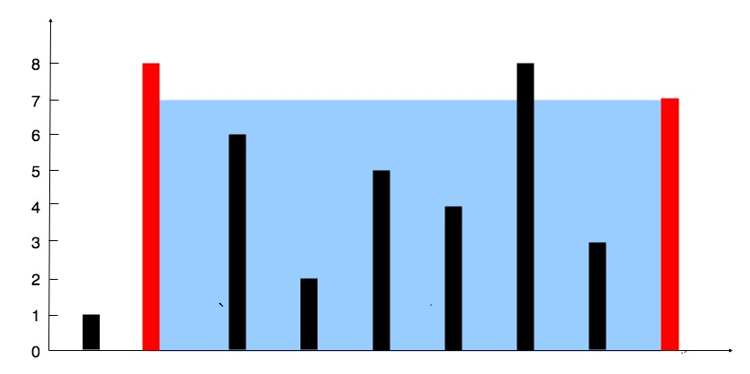

# Problem Decomposition

To create a container, we need **two lines** and height of the container will be **shotest height**, otherwise water will overflow. 

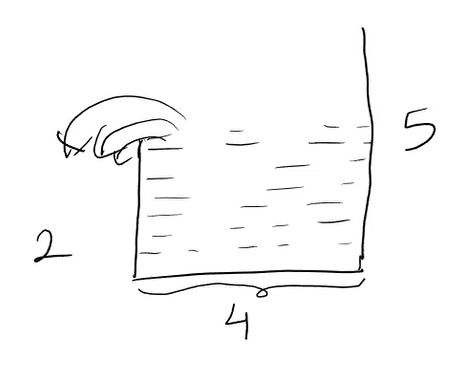

Goal is to find container that can store maximum amount of water. That is, container with **maximum area**.
1. Pick **two lines** such that they form the **maximum area** container with the x-axis. This leads us to **Two Pointer Technique**
2. To find **maximum area**, we have to find **maximum hieght** and **maximum width** possible to form a container.

# Intuition (Why Two Pointers Work)

Think like this:
* **Width** is maximum when we take the **outermost lines**.
* But **height** is limited by the **shorter line**.

So to **maximize area**:
1. Start with two **extreme lines** → **maximum width**.
2. Area depends on the **minimum height**, so:
    * If **left** line is shorter → moving right might improve height. ***(logic to move left pointer)***
    * If **right** line is shorter → moving left might improve height. ***(logic to move right pointer)***

**👉 Only move the pointer pointing to the shorter height.**

Because the shorter height is the limiting factor.

This is the key insight.

# Technique (Step-by-step)

1. Initialize two pointers:

```
left = 0
right = n-1
max_area = 0
```

2. While left < right:

    * Calculate area = **width * heigth** = `(right−left) × min⁡(height[left], height[right])`
    * Update **max_area**.
    * Move the pointer pointing to the **smaller** height.
        * if `left pointer height < right pointer height` >> **move left pointer to right** might improve the height.
        * if `right pointer height < left pointer height` >> **move right pointer to left** might improve the height. 

3. Return **max_area**.

# Solution

In [3]:
def maxArea(height):
    left = 0
    right = len(height) - 1
    max_area = 0

    while left < right:
        w = right - left
        h = min(height[left], height[right])
        area = w * h
        max_area = max(max_area, area)

        # If left line is shorter → moving right might improve height.
        if height[left] < height[right]:
            left = left + 1
        # If right line is shorter → moving left might improve height.
        elif height[left] > height[right]:
            right = right - 1
        # if both left & right are equal then moving both pointer might improve the height
        else:
            left = left + 1
            right -= 1

    return max_area

height = [1,8,6,2,5,4,8,3,7]
print(maxArea(height))

49
